In [4]:
import pandas as pd

import requests

In [11]:
list_file_endpoint = "https://app.data.gov.hk/v1/historical-archive/list-files"

query_params = {
    "start": "20180101",
    "end": "20260601",
    "category": "environment",
    "search": "Past record of Air Quality Health Index",
    "format": "csv",
      }

response = requests.get(list_file_endpoint, params=query_params)
print(response.json())

{'file-count': 420, 'files': [{'category-id': 'environment', 'data_dictionary': 'http://www.aqhi.gov.hk/psi/dd/hk_aqhisc_en.pdf', 'dataset-id': 'hk-epd-airteam-past-record-of-air-quality-health-index-sc', 'dataset-name-en': 'Past record of Air Quality Health Index (Simplified Chinese Version)', 'dataset-name-sc': '过去空气质素健康指数记录（简体中文版）', 'dataset-name-tc': '過去空氣質素健康指數記錄（簡體中文版）', 'format': 'csv', 'provider-id': 'hk-epd', 'resource-name-en': 'Past record of Air Quality Health Index  (Simplified Chinese) Dec 2013', 'resource-name-sc': '过去空气质素健康指数记录 (简体中文)2013年12月', 'resource-name-tc': '過去空氣質素健康指數記錄(簡體中文)2013件12月', 'schema': '', 'total-size': 5132, 'url': 'https://www.aqhi.gov.hk/epd/ddata/html/history/2013/201312_ChS.csv', 'version-count': 2}, {'category-id': 'environment', 'data_dictionary': 'http://www.aqhi.gov.hk/psi/dd/hk_aqhitc_en.pdf', 'dataset-id': 'hk-epd-airteam-past-record-of-air-quality-health-index-tc', 'dataset-name-en': 'Past record of Air Quality Health Index (Traditional Chi

In [26]:
get_file_endpoint = "https://app.data.gov.hk/v1/historical-archive/get-file"
time = "20230701"
url = 'https://www.aqhi.gov.hk/epd/ddata/html/history/2023/202307_Eng.csv'


query_params = {
    "url": url,
    "time": time,
      }

response = requests.get(get_file_endpoint, params=query_params)
print(response)
print(response.text)
print(response.json())


<Response [404]>
{"message": "Not Found"}
{'message': 'Not Found'}


In [42]:
from pathlib import Path
import os

In [50]:
root = Path("C:/Users/bryan/git/dse_pollution_corr/data")

In [ ]:
def read_air_quality_df(path):
    df = pd.read_csv(path, skiprows=7)
    df['Date'] = df['Date'].ffill()
    df['file_name'] = path
    return df

In [52]:
#  read all files
file_names = os.listdir(root / "air_quality")
air_quality_df = pd.DataFrame()
for file_name in file_names:
    path = root / "air_quality" / file_name
    temp_df = read_air_quality_df(path)
    air_quality_df = pd.concat([air_quality_df, temp_df], ignore_index=True)

print(air_quality_df['file_name'].value_counts())

file_name
C:\Users\bryan\git\dse_pollution_corr\data\air_quality\201401_Eng.csv    775
C:\Users\bryan\git\dse_pollution_corr\data\air_quality\201608_Eng.csv    775
C:\Users\bryan\git\dse_pollution_corr\data\air_quality\201907_Eng.csv    775
C:\Users\bryan\git\dse_pollution_corr\data\air_quality\201912_Eng.csv    775
C:\Users\bryan\git\dse_pollution_corr\data\air_quality\202005_Eng.csv    775
C:\Users\bryan\git\dse_pollution_corr\data\air_quality\202008_Eng.csv    775
C:\Users\bryan\git\dse_pollution_corr\data\air_quality\202407_Eng.csv    775
C:\Users\bryan\git\dse_pollution_corr\data\air_quality\202408_Eng.csv    775
C:\Users\bryan\git\dse_pollution_corr\data\air_quality\201611_Eng.csv    750
C:\Users\bryan\git\dse_pollution_corr\data\air_quality\202411_Eng.csv    750
C:\Users\bryan\git\dse_pollution_corr\data\air_quality\202504_Eng.csv    750
C:\Users\bryan\git\dse_pollution_corr\data\air_quality\202506_Eng.csv    750
C:\Users\bryan\git\dse_pollution_corr\data\air_quality\202502_Eng.

In [51]:
def read_wind_direction(path):
    df = pd.read_csv(path, skiprows=2)
    df['file_name'] = path
    return df

In [53]:
path = root / "wind_direction" / "daily_KP_PDIR_ALL.csv"
wind_direction_df = read_wind_direction(path)

In [61]:
# for col in ["年/Year", "月/Month", "日/Day"]:
#     wind_direction_df[col] = wind_direction_df[col].astype(int)
# wind_direction_df.head()

In [84]:
# use just the noon row for air quality, and mong kok
air_quality_df_to_join = air_quality_df[air_quality_df["Hour"]=="12"]
air_quality_df_to_join['air_quality'] = [float(a.replace("*","")) if isinstance(a, str) else float(a) for a in air_quality_df_to_join['Mong Kok']]
air_quality_df_to_join['年/Year'] = [str(a.split("-")[0]) for a in air_quality_df_to_join['Date']]
air_quality_df_to_join['月/Month'] = [float(a.split("-")[1]) for a in air_quality_df_to_join['Date']]
air_quality_df_to_join['日/Day'] = [float(a.split("-")[2]) for a in air_quality_df_to_join['Date']]
air_quality_df_to_join.head()

,Date,Hour,Central/Western,Eastern,Kwun Tong,Sham Shui Po,Kwai Chung,Tsuen Wan,Yuen Long,Tuen Mun,...,Central,Mong Kok,file_name,Tseung Kwan O,Southern,North,air_quality,年/Year,月/Month,日/Day
11,2013-12-30,12,6.0,5.0,6.0,6.0,6,6,6,6.0,...,8.0,6.0,C:\Users\bryan\git\dse_pollution_corr\data\air...,NaN,NaN,NaN,6.0,2013,12.0,30.0
36,2013-12-31,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,C:\Users\bryan\git\dse_pollution_corr\data\air...,NaN,NaN,NaN,NaN,2013,12.0,31.0
61,2014-01-01,12,6,5,5,6,5,6,5,5,...,6,6,C:\Users\bryan\git\dse_pollution_corr\data\air...,NaN,NaN,NaN,6.0,2014,1.0,1.0
86,2014-01-02,12,5,5*,5,6,6,5,6,6,...,6,6,C:\Users\bryan\git\dse_pollution_corr\data\air...,NaN,NaN,NaN,6.0,2014,1.0,2.0
111,2014-01-03,12,6,6,7,7,7*,7,6,7,...,9,7,C:\Users\bryan\git\dse_pollution_corr\data\air...,NaN,NaN,NaN,7.0,2014,1.0,3.0


In [85]:
merged_df = wind_direction_df.merge(air_quality_df_to_join, 
                                   on=["年/Year", "月/Month", "日/Day"],
                                    how='inner')

In [86]:
print(merged_df.shape)
merged_df[['數值/Value','air_quality']].head()

(398, 28)


,數值/Value,air_quality
0,260,6.0
1,290,NaN
2,130,6.0
3,130,6.0
4,280,7.0


In [87]:
merged_df['air_quality'].value_counts()

air_quality
3.0    157
4.0    102
2.0     78
5.0     33
6.0     18
7.0      6
8.0      3
Name: count, dtype: int64

In [92]:
merged_df['wind_direction'] = merged_df['數值/Value'].astype(float)

In [88]:
import matplotlib.pyplot as plt


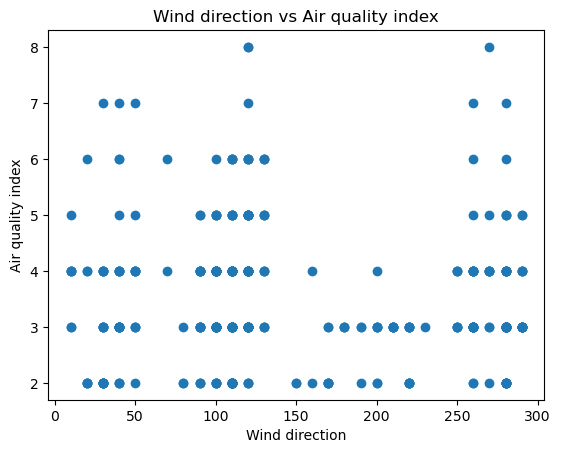

In [93]:
plt.scatter(merged_df['wind_direction'], merged_df['air_quality'])
plt.title("Wind direction vs Air quality index")
plt.xlabel("Wind direction")
plt.ylabel("Air quality index")
plt.show()

In [ ]:
file_names = os.listdir(root / "dse_timetable")
file_names

['2018_DSE_Timetable.pdf',
 '2019_DSE_Timetable.pdf',
 '2020_DSE_Timetable.pdf',
 '2021_DSE_Timetable.pdf',
 '2022_DSE_Timetable.pdf',
 '2023_DSE_Timetable.pdf',
 '2024_DSE_Timetable.pdf',
 '2025_DSE_Timetable.pdf',
 '2026_dse_timetable.pdf']

In [97]:
import pdfplumber

In [111]:
def read_dse_timetable(path):
    with pdfplumber.open(path) as pdf:
        first_page = pdf.pages[0]
        table_data = first_page.extract_table()
    if table_data:
        df = pd.DataFrame(table_data[1:], columns=table_data[0])

        # the subject column can have multiple lines in one row, delimited by \n. they should be separate rows.
        df['subject'] = df['Subject / Paper'].str.split('\n')
        df = df.explode('subject')
        # another issue: sometimes the date spans multiple rows, if both date and subject have multiple rows then they get split
        # causing 1 row with a chinese date and 1 row with english translation. ill just leave this for now
        df['file_name'] = path
        return df

In [112]:
dse_timetable_df = pd.DataFrame()
for file_name in file_names:
    path = root / "dse_timetable" / file_name
    temp_df = read_dse_timetable(path)
    dse_timetable_df = pd.concat([dse_timetable_df, temp_df], ignore_index=True)
print(dse_timetable_df['file_name'].value_counts())

file_name
C:\Users\bryan\git\dse_pollution_corr\data\dse_timetable\2021_DSE_Timetable.pdf    60
C:\Users\bryan\git\dse_pollution_corr\data\dse_timetable\2019_DSE_Timetable.pdf    59
C:\Users\bryan\git\dse_pollution_corr\data\dse_timetable\2022_DSE_Timetable.pdf    59
C:\Users\bryan\git\dse_pollution_corr\data\dse_timetable\2018_DSE_Timetable.pdf    58
C:\Users\bryan\git\dse_pollution_corr\data\dse_timetable\2020_DSE_Timetable.pdf    58
C:\Users\bryan\git\dse_pollution_corr\data\dse_timetable\2023_DSE_Timetable.pdf    57
C:\Users\bryan\git\dse_pollution_corr\data\dse_timetable\2025_DSE_Timetable.pdf    52
C:\Users\bryan\git\dse_pollution_corr\data\dse_timetable\2026_dse_timetable.pdf    51
C:\Users\bryan\git\dse_pollution_corr\data\dse_timetable\2024_DSE_Timetable.pdf    49
Name: count, dtype: int64


In [113]:
file_names = os.listdir(root / "dse_results")
file_names

['dseexamstat19_5.pdf',
 'dseexamstat20_5.pdf',
 'dseexamstat21_5.pdf',
 'dseexamstat22_5.pdf',
 'dseexamstat23_5.pdf',
 'dseexamstat24_5.pdf',
 'dseexamstat25_5.pdf']

In [116]:
file_name = file_names[-1]
path = root / "dse_results" / file_name

In [117]:
all_dfs = []
with pdfplumber.open(path) as pdf:
    for page_num, page in enumerate(pdf.pages, start=1):
        tables = page.extract_tables()
        for table_index, table in enumerate(tables, start=1):
            # Uses the first row as the column headers
            df = pd.DataFrame(table[1:], columns=table[0])
            all_dfs.append(df)

In [123]:
print(len(all_dfs))
# display(all_dfs[0].head())
# display(all_dfs[5].head(20))
# display(all_dfs[-1].head())
score_dfs = [a for a in all_dfs if "科目\nSubject" in a.columns or "人數及百分率 Number and percentage" in a.columns]
print(len(score_dfs))

78
21


In [124]:
score_dfs[0]

,科目\nSubject,NaN,性別,報考\n人數\nNo.\nentered,,中文,人數及百分率 Number and percentage,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,NaN,NaN,NaN,NaN,出席,作答,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,,NaN,人數,Chinese,,,,,,2+,1+,
2,NaN,NaN,Gender,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,No. sat,version,5**,5*+,5+,4+,3+,NaN,NaN,U
4,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,,%,,,,,,NaN,NaN,
6,生物\nBiology,NaN,男生\nMale,6 097,5 925,41.3,163\n2.8%,592\n10.0%,1 380\n23.3%,3 018\n50.9%,4 477\n75.6%,5 449\n92.0%,5 742\n96.9%,183\n3.1%
7,NaN,NaN,女生,7 562,7 347,37.0,99,455,1 207,3 149,5 324,6 778,7 176,171
8,NaN,NaN,Female,NaN,NaN,NaN,1.3%,6.2%,16.4%,42.9%,72.5%,92.3%,97.7%,2.3%
9,NaN,NaN,總數\nTotal,13 659,13 272,38.9,262\n2.0%,1 047\n7.9%,2 587\n19.5%,6 167\n46.5%,9 801\n73.8%,12 227\n92.1%,12 918\n97.3%,354\n2.7%
